In [50]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [51]:

# Download latest version
folder_path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", folder_path)

Path to dataset files: /home/kabuga/.cache/kagglehub/datasets/yasserh/wine-quality-dataset/versions/1


In [52]:
all_files = os.listdir(folder_path)
print("\n--- Files found inside this dataset ---")
for file in all_files:
    print(f"- {file}")


--- Files found inside this dataset ---
- WineQT.csv


In [53]:
csv_file_name = 'WineQT.csv'

In [54]:
csv_path = os.path.join(folder_path , csv_file_name)
df = pd.read_csv(csv_path)
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [55]:
# 1. Check for missing values
print("Missing values per column:\n", X.isnull().sum())

# 2. Check the data types of your columns
print("\nData types of columns:\n", X.dtypes)

# 3. Check the shape
print("\nShape of X:", X.shape)

Missing values per column:
 clusters            0
silhouette_score    0
dtype: int64

Data types of columns:
 clusters              int64
silhouette_score    float64
dtype: object

Shape of X: (8, 2)


In [56]:
print(df.shape) # has 1143 rows and 13 columns
print(df.isna().count()) #  no msiing values

(1143, 13)
fixed acidity           1143
volatile acidity        1143
citric acid             1143
residual sugar          1143
chlorides               1143
free sulfur dioxide     1143
total sulfur dioxide    1143
density                 1143
pH                      1143
sulphates               1143
alcohol                 1143
quality                 1143
Id                      1143
dtype: int64


In [57]:
# PREPROCESSING AND MODEL TRAINING USIN CLUSTERING

# There are steps we need to follow

# 1. We need to determine the suitable number of clusters using (elobow method or silhoute score)
# 2. We scale our features using one of the preprocessing steps
# 3. We use the Kmeans model

# We can combine step 2 and 3 using a pipeline

In [58]:
# TERMINLOGIES

# 1. Centroid = Values which determine which cluster a data point will belong(each cluster has its own centroid)

# 2. crosstab = this is a cross tabulation table (a truth matrix ) to cross reference the computers numbered labels(predictions) against actual names

# 3. inertia = measures how far the values are from the centroids or har far the clusters are spread apart

# 4. elbow method = this is a technique that we use to determine the best clusters to use(plot inertia against the range of clusters)

# 5. siloute score = Another technique for determing the total number of clusters. Used when its difficult to determine clusters using elbow method. This measures how seperated the clusters are from each other (RANGES FROM 0 TO 1) . THE HIGHER THE SCORE THE BETTER THE CLUSTER

# PREPROCESSING TECHNIQUES

#1. Standard Scaler = Used when there are no crazy outliers in your features
# 2. Minmaxscaler = Used whe the data in the features is between 0 and 1 (neural networks , image processing)
# 3. Robust Scaler = Used when in the features we have crazy outliers(slary like of billionares )
#4. Max Abs Scaler = Used when you have sparse data (zero like test word count)
# 5. Normalizer = Comparing proportions of features within a row rather than sizze of numbers. EG:
                                # CLUSTERING TEXT DOCS OF DIFFERENT LENGTHS
                                # ANALYZING CUSTOMER TEXT SPENDING HABITS BY PERCENTAGE OF INCOME RATHER THAN DOLLAR AMOUNTS


In [59]:
X = df

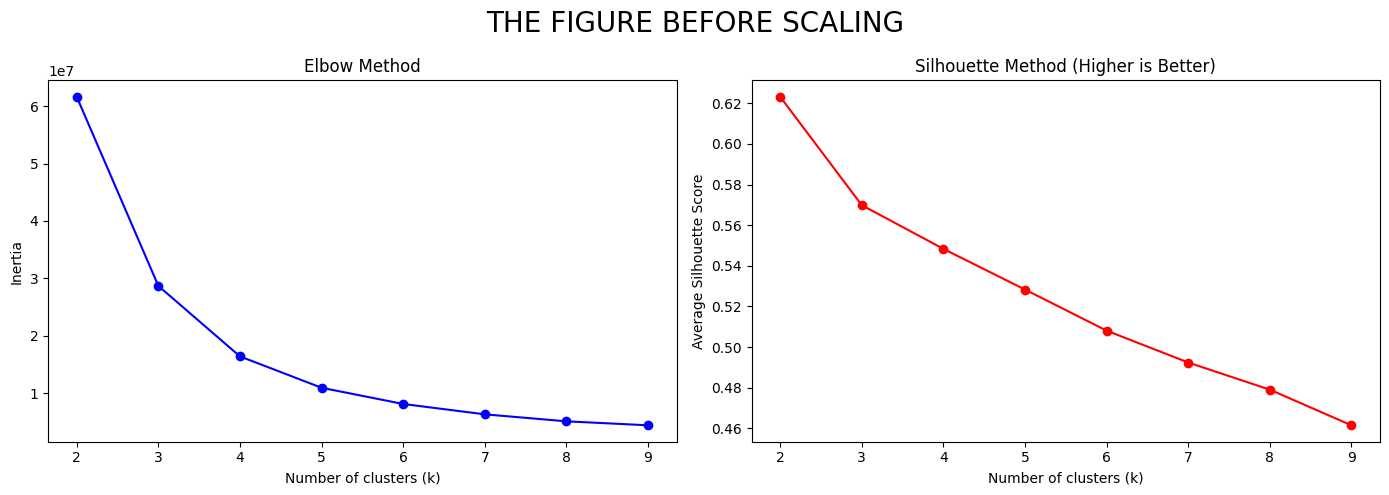

In [69]:
# THE FIGURE BEFORE SCALING

clusters = range(2 , 10) # sillhoute requires a minimum of 2 clusters
inertia = []
silhouette = []

for i in clusters:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    if i < len(X):
        silhouette.append(silhouette_score(X, kmeans.labels_))
    else:
        silhouette.append(np.nan)


# Create a clean side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Elbow
ax1.plot(clusters, inertia, marker='o', color='b')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
fig.suptitle("THE FIGURE BEFORE SCALING", fontsize=20)

# Plot Silhouette
ax2.plot(clusters, silhouette, marker='o', color='r')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Average Silhouette Score')
ax2.set_title('Silhouette Method (Higher is Better)')

plt.tight_layout()
plt.show()

In [61]:
X = df # we can take all the columns as the faetures

# we first scale our data

scaler = StandardScaler()
scaler.fit(X)
StandardScaler(copy = True , with_mean = True , with_std = True)
X_scaled = scaler.transform(X)

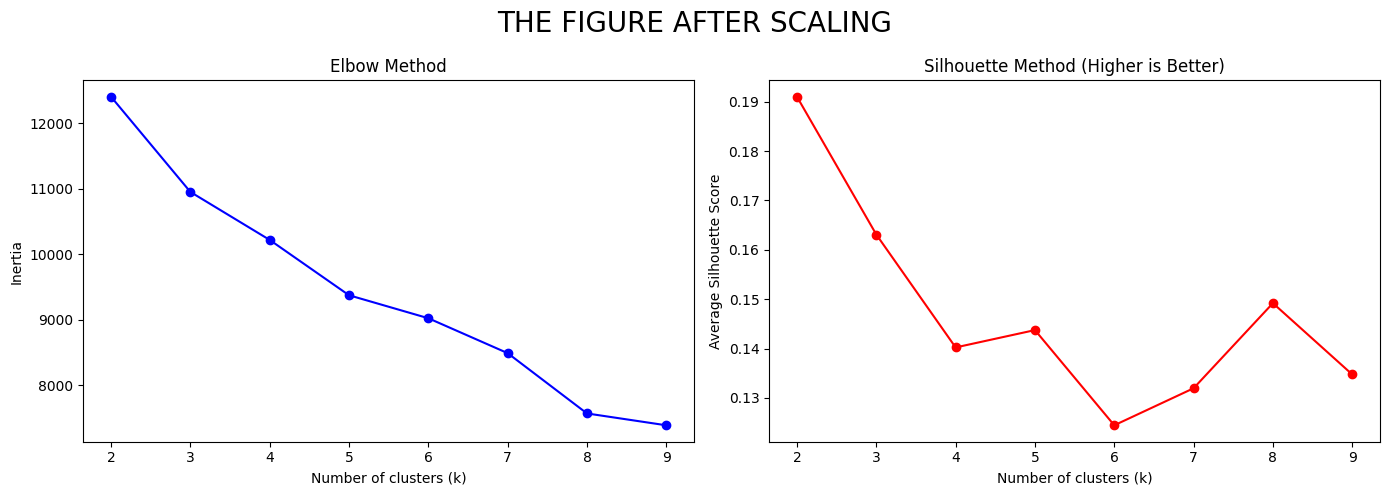

In [70]:


# we need to determine the number of clusters

clusters = range(2 , 10) # sillhoute requires a minimum of 2 clusters
inertia = []
silhouette = []

for i in clusters:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled , kmeans.labels_))

# Create a clean side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Elbow
ax1.plot(clusters, inertia, marker='o', color='b')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
fig.suptitle("THE FIGURE AFTER SCALING", fontsize=20)

# Plot Silhouette
ax2.plot(clusters, silhouette, marker='o', color='r')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Average Silhouette Score')
ax2.set_title('Silhouette Method (Higher is Better)')

plt.tight_layout()
plt.show()

In [63]:
print(inertia)

[12401.548107172235, 10949.831468630218, 10217.636216204177, 9373.682564714787, 9022.836083739252, 8490.46383053749, 7570.518508700122, 7389.758485466246]


In [64]:
# print(silhouette)
# print(max(silhouette))

df = pd.DataFrame({
    'clusters': list(clusters),
    'silhouette_score': silhouette + [np.nan] * (len(clusters) - len(silhouette)),
    'inertia': inertia + [np.nan] * (len(clusters) - len(inertia))
})
df

# WE CAN SEE THAT THE SUITABLE CLUSTERS = 2 HAS THE HIGHESAT SCORE

,clusters,silhouette_score,inertia
0,2,0.190998,12401.548107
1,3,0.163097,10949.831469
2,4,0.140231,10217.636216
3,5,0.143743,9373.682565
4,6,0.124462,9022.836084
5,7,0.131964,8490.463831
6,8,0.149196,7570.518509
7,9,0.134758,7389.758485
